<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Criterios de División y Árboles de Clasificación 📊
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 09
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/09%20-%20Decision%20Trees/01_Criterios_Division_y_Arboles_Clasificacion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Problema de la División en Árboles Binarios ✂️

Como vimos en la introducción, un árbol de decisión es en esencia un **árbol binario**. Comenzamos en el nodo raíz, elegimos una rama según la condición impuesta en el nodo interno y descendemos sucesivamente hasta una hoja terminal.

### ¿Cómo se decide qué condición colocar en un nodo no terminal?
¿Qué métrica determina el mejor corte? La calidad de una división candidata se cuantifica mediante una **función de impureza o función de pérdida**:
* El objetivo es seleccionar el par óptimo $(j, t_j)$ —el predictor $X_j$ y el umbral numérico $t_j$— que **minimice la impureza promedio ponderada** de las regiones hijas resultantes.

---
## 2. El Error de Clasificación (*Classification Error*) 🎯

Formulación Matemática: Calidad de la División
  Supongamos que disponemos de $J$ predictores y $K$ clases posibles.
  upongamos que seleccionamos el $j$-ésimo predictor y dividimos una región que contiene $N$ puntos de entrenamiento a lo largo del umbral $t_j \in \mathbb{R}$.
  Podemos evaluar la calidad de esta división midiendo el <b>error de clasificación</b> cometido por cada una de las dos regiones recién creadas, $R_1$ y $R_2$:

  $$\text{Error}(i \mid j, t_j) = 1 - \max_k p(k \mid R_i)$$
  
  donde $p(k \mid R_i)$ es la proporción de puntos de entrenamiento dentro de la región $R_i$ que pertenecen a la clase $k$.


---
Ejemplo Numérico y Minimización Ponderada 📐

Para comprender cómo un árbol evalúa y selecciona la mejor partición $(j, t_j)$, analicemos el cálculo del **Error de Clasificación** en dos regiones recién creadas ($R_1$ y $R_2$):

$$\text{Error}(i \mid j, t_j) = 1 - \max_k p(k \mid R_i)$$

donde $p(k \mid R_i)$ es la proporción de muestras en la región $R_i$ pertenecientes a la clase $k$.

### 📌 Ejemplo de Cálculo Numérico de Error por Región

| Región | Muestras Clase 1 | Muestras Clase 2 | Error de Clasificación: $\text{Error}(i \mid j, t_j)$ |
|:---:|:---:|:---:|:---|
| **$R_1$** | 0 | 6 | $1 - \max\{6/6, 0/6\} = 1 - 1 = \mathbf{0}$ (Región 100% pura) |
| **$R_2$** | 5 | 8 | $1 - \max\{5/13, 8/13\} = 1 - 8/13 = \mathbf{5/13} \approx 0.3846$ |

El algoritmo busca el predictor $j$ y el umbral $t_j$ que **minimicen el error promedio ponderado** por el tamaño de cada región:

$$\min_{j, t_j} \left\{ \frac{N_1}{N} \text{Error}(1 \mid j, t_j) + \frac{N_2}{N} \text{Error}(2 \mid j, t_j) \right\}$$

donde $N_i$ es el número de puntos dentro de la región $R_i$, y $N = N_1 + N_2$.

> 💡 **Transición hacia Regresión:** En regresión, en lugar del error de clase, minimizamos la **suma ponderada de cuadrados de los residuos (MSE)** en cada región:
>
> $$\min_{j, t_j} \left\{ \sum_{i \in R_1(j, t_j)} (y_i - \bar{y}_{R_1})^2 + \sum_{i \in R_2(j, t_j)} (y_i - \bar{y}_{R_2})^2 \right\}$$


---
## 4. Criterios de Impureza Avanzados: Índice Gini y Entropía 🔬

Aunque el error de clasificación es conceptualmente directo, **no es lo suficientemente sensible a la pureza de los nodos** para construir árboles profundos. Por ello, Scikit-Learn utiliza por defecto dos medidas analíticas superiores:

### 1. El Índice de Impureza de Gini (*Gini Impurity*):
$$\text{Gini} = 1 - \sum_{k=1}^K p_k^2$$
donde $p_k$ es la proporción de muestras del nodo que pertenecen a la clase $k$.
* **Significado:** Mide la probabilidad de clasificar erróneamente un elemento si fuese etiquetado aleatoriamente según la distribución de clases del nodo.
* **Rango (en 2 clases):** Varía entre **$0.0$** (nodo perfectamente puro, todos de una sola clase) y **$0.5$** (máxima impureza, $50\%$ de cada clase).

### 2. La Entropía (*Information Gain*):
$$\text{Entropía} = - \sum_{k=1}^K p_k \log_2(p_k)$$
* **Significado:** Proveniente de la Teoría de la Información de Shannon, mide la incertidumbre o sorpresa del nodo.
* **Rango (en 2 clases):** Varía entre **$0.0$** (pureza absoluta, sin incertidumbre) y **$1.0$** (máximo desorden, $50\% / 50\%$).

> 📌 En Scikit-Learn, el parámetro `criterion='gini'` (predeterminado) o `criterion='entropy'` permite elegir entre ambos criterios.

In [4]:
import os, sys, time, urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

# Función de utilidad para cargar datasets de forma segura
def load_dataset(filename, module_folder="09 - Decision Trees"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path
    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        try:
            urllib.request.urlretrieve(raw_url, target_path)
        except Exception:
            fallbacks = {'spam.csv': 'https://raw.githubusercontent.com/datasets/machine-learning/master/spambase.csv'}
            if filename in fallbacks:
                urllib.request.urlretrieve(fallbacks[filename], target_path)
            else:
                raise
    return target_path

print("🚀 Entorno configurado exitosamente para el Cuaderno 01.")

🚀 Entorno configurado exitosamente para el Cuaderno 01.


---
## 5. Caso de Estudio: Clasificación de Correo No Deseado (*Spambase Dataset*) 📧

Trabajamos con el conjunto de datos de correo electrónico no deseado (*Spambase*), compuesto por **57 predictores continuos** (frecuencias de palabras clave y caracteres especiales) y una variable objetivo binaria `Spam` ($1 = \text{Spam}, 0 = \text{Legítimo}$).

Realizamos una partición 70/30 mediante muestreo aleatorio uniforme con máscara booleana para verificar el balance de clases:

In [5]:
# 1. Importación y nomenclatura de columnas
ruta_spam = load_dataset('spam.csv', '09 - Decision Trees')
spam_df = pd.read_csv(ruta_spam, header=None)
columnas = [f"Caracteristica_{i+1}" for i in range(spam_df.shape[1] - 1)] + ['Spam']
spam_df.columns = columnas

# 2. Partición manual 70-30 con máscara booleana uniforme
np.random.seed(42)
muestras_uniformes = np.random.rand(len(spam_df))
msk = muestras_uniformes < 0.70

data_train = spam_df[msk]
data_test  = spam_df[~msk]

x_train, y_train = data_train.drop(columns=['Spam']), data_train['Spam'].values
x_test,  y_test  = data_test.drop(columns=['Spam']),  data_test['Spam'].values

print(f"Dimensiones Entrenamiento : {data_train.shape}")
print(f"Dimensiones Prueba        : {data_test.shape}")
print(f"Proporción de Spam en Train: {y_train.mean() * 100:.2f}%")
print(f"Proporción de Spam en Test : {y_test.mean() * 100:.2f}%")
display(x_train.head(3))

Dimensiones Entrenamiento : (3262, 58)
Dimensiones Prueba        : (1339, 58)
Proporción de Spam en Train: 39.18%
Proporción de Spam en Test : 39.96%


,Caracteristica_1,Caracteristica_2,Caracteristica_3,Caracteristica_4,Caracteristica_5,Caracteristica_6,Caracteristica_7,Caracteristica_8,Caracteristica_9,Caracteristica_10,...,Caracteristica_48,Caracteristica_49,Caracteristica_50,Caracteristica_51,Caracteristica_52,Caracteristica_53,Caracteristica_54,Caracteristica_55,Caracteristica_56,Caracteristica_57
0,0.0,0.64,0.64,0.0,0.32,0.0,0.00,0.00,0.00,0.00,...,0.0,0.0,0.000,0.0,0.778,0.0,0.0,3.756,61,278
3,0.0,0.00,0.00,0.0,0.63,0.0,0.31,0.63,0.31,0.63,...,0.0,0.0,0.137,0.0,0.137,0.0,0.0,3.537,40,191
4,0.0,0.00,0.00,0.0,0.63,0.0,0.31,0.63,0.31,0.63,...,0.0,0.0,0.135,0.0,0.135,0.0,0.0,3.537,40,191


---
## 6. Búsqueda de la Profundidad Óptima (`max_depth`) con Validación Cruzada 🎯

Ajustamos un árbol de decisión variando su profundidad máxima de $3$ a $31$ en pasos de $4$. Para cada profundidad, calculamos el puntaje de exactitud mediante **validación cruzada de 5 pliegues (*5-Fold CV*)** sobre el conjunto de entrenamiento:

<Figure size 900x400 with 0 Axes>

Text(0.5, 0, 'Profundidad Máxima del Árbol (max_depth)')

Text(0, 0.5, 'Exactitud en Validación Cruzada')

Text(0.5, 1.0, 'Variación de la Exactitud con la Profundidad (Árbol Simple)')

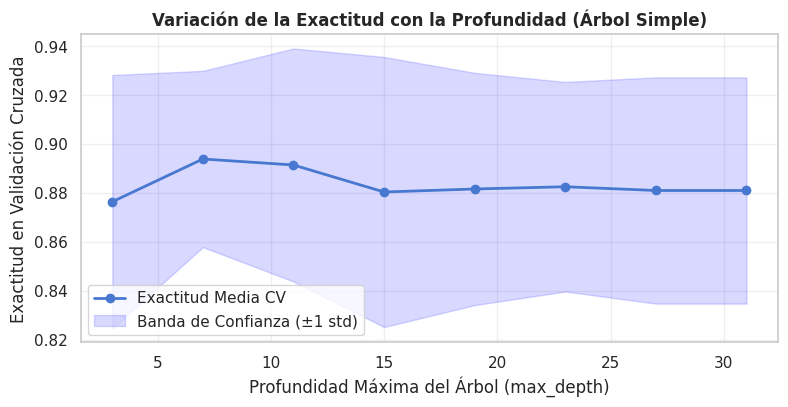

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

profundidades = list(range(3, 32, 4))
cv_medias = {}
cv_todas = {}

for p in profundidades:
    modelo = DecisionTreeClassifier(max_depth=p, criterion='gini', random_state=42)
    scores = cross_val_score(modelo, x_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_todas[p]  = scores
    cv_medias[p] = scores.mean()

# Visualización con bandas de confianza (Media ± 1 Desviación Estándar)
x_vals = list(cv_medias.keys())
y_vals = np.array(list(cv_medias.values()))
stds   = np.array([np.std(cv_todas[p]) for p in x_vals])

plt.figure(figsize=(9, 4))
plt.plot(x_vals, y_vals, 'b-o', lw=2, label='Exactitud Media CV')
plt.fill_between(x_vals, y_vals - stds, y_vals + stds, color='blue', alpha=0.15, label='Banda de Confianza (±1 std)')
plt.xlabel('Profundidad Máxima del Árbol (max_depth)')
plt.ylabel('Exactitud en Validación Cruzada')
plt.title('Variación de la Exactitud con la Profundidad (Árbol Simple)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Axes: xlabel='Profundidad Máxima', ylabel='Exactitud CV'>

Text(0.5, 1.0, 'Distribución de Exactitud por Pliegue según la Profundidad')

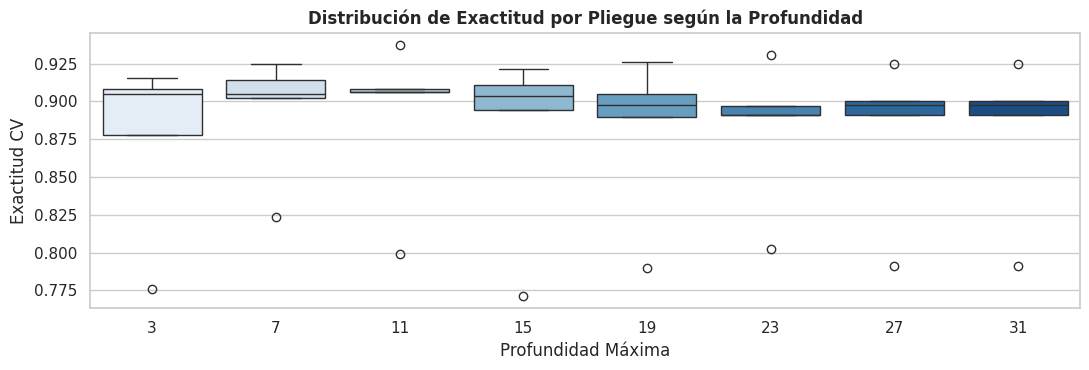

⭐ La profundidad óptima encontrada fue: 7 (Exactitud CV: 89.39%)


In [7]:
# Transformación de diccionario a DataFrame largo con pd.melt para graficar distribuciones
df_scores = pd.DataFrame(cv_todas)
df_melted = pd.melt(df_scores, var_name='Profundidad Máxima', value_name='Exactitud CV')

fig, ax = plt.subplots(figsize=(11, 3.8))
sns.boxplot(x='Profundidad Máxima', y='Exactitud CV', data=df_melted, palette='Blues', ax=ax)
ax.set_title('Distribución de Exactitud por Pliegue según la Profundidad', fontweight='bold')
plt.tight_layout()
plt.show()

# Identificación programática de la mejor profundidad
mejor_profundidad = sorted(cv_medias, key=cv_medias.get, reverse=True)[0]
print(f"⭐ La profundidad óptima encontrada fue: {mejor_profundidad} (Exactitud CV: {cv_medias[mejor_profundidad]*100:.2f}%)")

DecisionTreeClassifier(max_depth=7, random_state=42)

Árbol de Decisión Óptimo (depth=7):
Exactitud en Entrenamiento : 94.24%
Exactitud en Prueba        : 90.89%

Matriz de Confusión sobre el Conjunto de Prueba:


Predicción Árbol,0,1,All
Clase Real,,,
0,757,47,804
1,75,460,535
All,832,507,1339


<Figure size 1800x800 with 0 Axes>

[Text(0.5648148148148148, 0.9, 'Caracteristica_53 <= 0.046\ngini = 0.477\nsamples = 3262\nvalue = [1984, 1278]\nclass = No Spam'),
 Text(0.2962962962962963, 0.7, 'Caracteristica_7 <= 0.065\ngini = 0.354\nsamples = 2431\nvalue = [1872, 559]\nclass = No Spam'),
 Text(0.4305555555555555, 0.8, 'True  '),
 Text(0.14814814814814814, 0.5, 'Caracteristica_52 <= 0.491\ngini = 0.27\nsamples = 2209\nvalue = [1853, 356]\nclass = No Spam'),
 Text(0.07407407407407407, 0.3, 'Caracteristica_16 <= 0.025\ngini = 0.186\nsamples = 1971\nvalue = [1767, 204]\nclass = No Spam'),
 Text(0.037037037037037035, 0.1, '\n  (...)  \n'),
 Text(0.1111111111111111, 0.1, '\n  (...)  \n'),
 Text(0.2222222222222222, 0.3, 'Caracteristica_56 <= 9.5\ngini = 0.462\nsamples = 238\nvalue = [86, 152]\nclass = Spam'),
 Text(0.18518518518518517, 0.1, '\n  (...)  \n'),
 Text(0.25925925925925924, 0.1, '\n  (...)  \n'),
 Text(0.4444444444444444, 0.5, 'Caracteristica_25 <= 0.315\ngini = 0.157\nsamples = 222\nvalue = [19, 203]\nclass =

Text(0.5, 1.0, 'Primeros 3 Niveles del Árbol de Clasificación Óptimo (depth=7)')

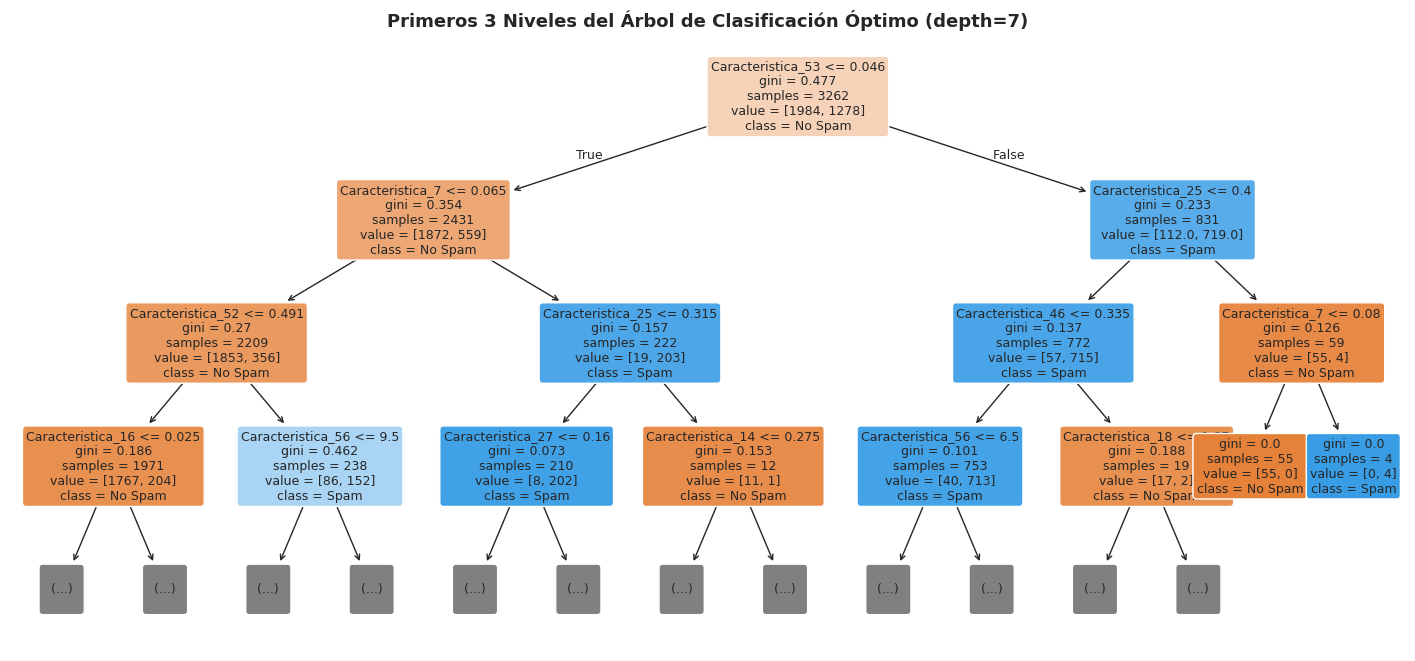

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

# 1. Entrenar el modelo final en todo el conjunto de entrenamiento con la mejor profundidad
arbol_optimo = DecisionTreeClassifier(max_depth=mejor_profundidad, criterion='gini', random_state=42)
arbol_optimo.fit(x_train, y_train)

acc_tr = accuracy_score(y_train, arbol_optimo.predict(x_train)) * 100
acc_ts = accuracy_score(y_test,  arbol_optimo.predict(x_test))  * 100

print("="*55)
print(f"Árbol de Decisión Óptimo (depth={mejor_profundidad}):")
print(f"Exactitud en Entrenamiento : {acc_tr:.2f}%")
print(f"Exactitud en Prueba        : {acc_ts:.2f}%")
print("="*55)

# 2. Matriz de confusión con pd.crosstab
print("\nMatriz de Confusión sobre el Conjunto de Prueba:")
matriz = pd.crosstab(
    y_test, arbol_optimo.predict(x_test),
    rownames=['Clase Real'], colnames=['Predicción Árbol'], margins=True
)
display(matriz)

# 3. Visualización gráfica de los primeros 3 niveles del árbol
plt.figure(figsize=(18, 8), dpi=100)
plot_tree(arbol_optimo, max_depth=3, feature_names=list(x_train.columns), class_names=['No Spam', 'Spam'], filled=True, rounded=True, fontsize=9)
plt.title(f"Primeros 3 Niveles del Árbol de Clasificación Óptimo (depth={mejor_profundidad})", fontsize=13, fontweight='bold')
plt.show()

---
## 7. Resumen y Conclusiones del Cuaderno 01 📌

1. **Criterios de Pureza:** El Error de Clasificación mide la fracción errónea simple ($1 - \max_k p_k$), mientras que Gini y Entropía miden la concentración probabilística y son mucho más sensibles para guiar el crecimiento del árbol.
2. **Minimización Ponderada:** Las divisiones siempre ponderan el error o impureza por la proporción de muestras que caen en cada región hija ($N_1/N$ y $N_2/N$).
3. **Curva de Validación:** Aumentar indiscriminadamente la profundidad incrementa la exactitud en entrenamiento hasta el 100%, pero deteriora el rendimiento en prueba debido al sobreajuste.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>